# The Deep Intuition: Raw Ranking
Both the Z-Score and the IQR methods rely on mathematical formulas to calculate where an outlier begins. But what if you don't want the math to dictate the boundary? What if you, the Data Scientist, just want to make an executive decision?

That is where the Percentile Method comes in. It ignores distributions and formulas entirely. It simply lines up all your data from lowest to highest and chops off the extreme ends based on a percentage you choose.

- - Example: "I don't care what the standard deviation is. I just want to cap the top 1% and the bottom 1% of our data."

When to use it: When you have specific domain knowledge (e.g., "We know the top 5% of our users are bot accounts, so just trim the 95th percentile and above").


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We are going to simulate a dataset of Daily App Downloads. Usually, it hovers around a few hundred, but on days when a marketing campaign goes viral, it spikes to insane numbers. We will use the 1st and 99th percentiles to trim and cap the data.

In [4]:
# creating dataset
np.random.seed(42)
normal_days = np.random.normal(500, 100, 1000)

# A few days where the app completely crashed (0 downloads)
crashes = np.array([0, 0, 5, 10])

# A few days where a TikTok went viral (massive spikes)
viral_days = np.array([4000, 4500, 5000, 5500])

data = np.concatenate([normal_days, crashes, viral_days])
df = pd.DataFrame({'Downloads': data})

df.shape

(1008, 1)

<Axes: ylabel='Downloads'>

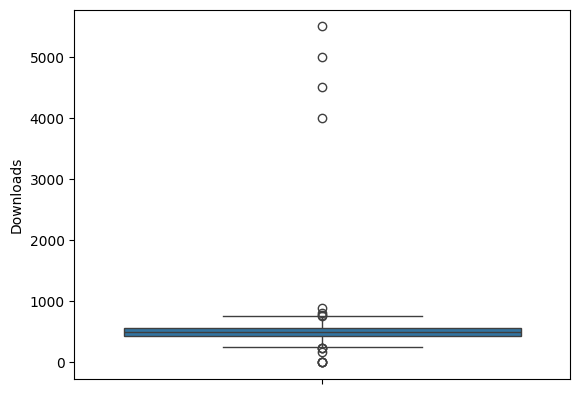

In [6]:
sns.boxplot(df['Downloads'])

In [7]:
# calculate percentile boundaries
lower_percentile = 0.01
upper_percentile = 0.99

lower_limit = df['Downloads'].quantile(lower_percentile)
upper_limit = df['Downloads'].quantile(upper_percentile)

print(f"1st Percentile (Lower Boundary): {lower_limit:.0f} downloads")
print(f"99th Percentile (Upper Boundary): {upper_limit:.0f} downloads")

1st Percentile (Lower Boundary): 270 downloads
99th Percentile (Upper Boundary): 752 downloads


In [8]:
# Count the outliers caught in this 1% net
outliers = df[(df['Downloads'] > upper_limit) | (df['Downloads'] < lower_limit)]
print(f"Total Outliers caught: {outliers.shape[0]}")

Total Outliers caught: 22


In [9]:
# Trimming
df_trimmed = df[(df['Downloads'] <= upper_limit) & (df['Downloads'] >= lower_limit)]

# Capping (Winsorization)
df_capped = df.copy()
df_capped['Downloads'] = np.where(
    df_capped['Downloads'] > upper_limit, upper_limit,
    np.where(df_capped['Downloads'] < lower_limit, lower_limit, df_capped['Downloads'])
)

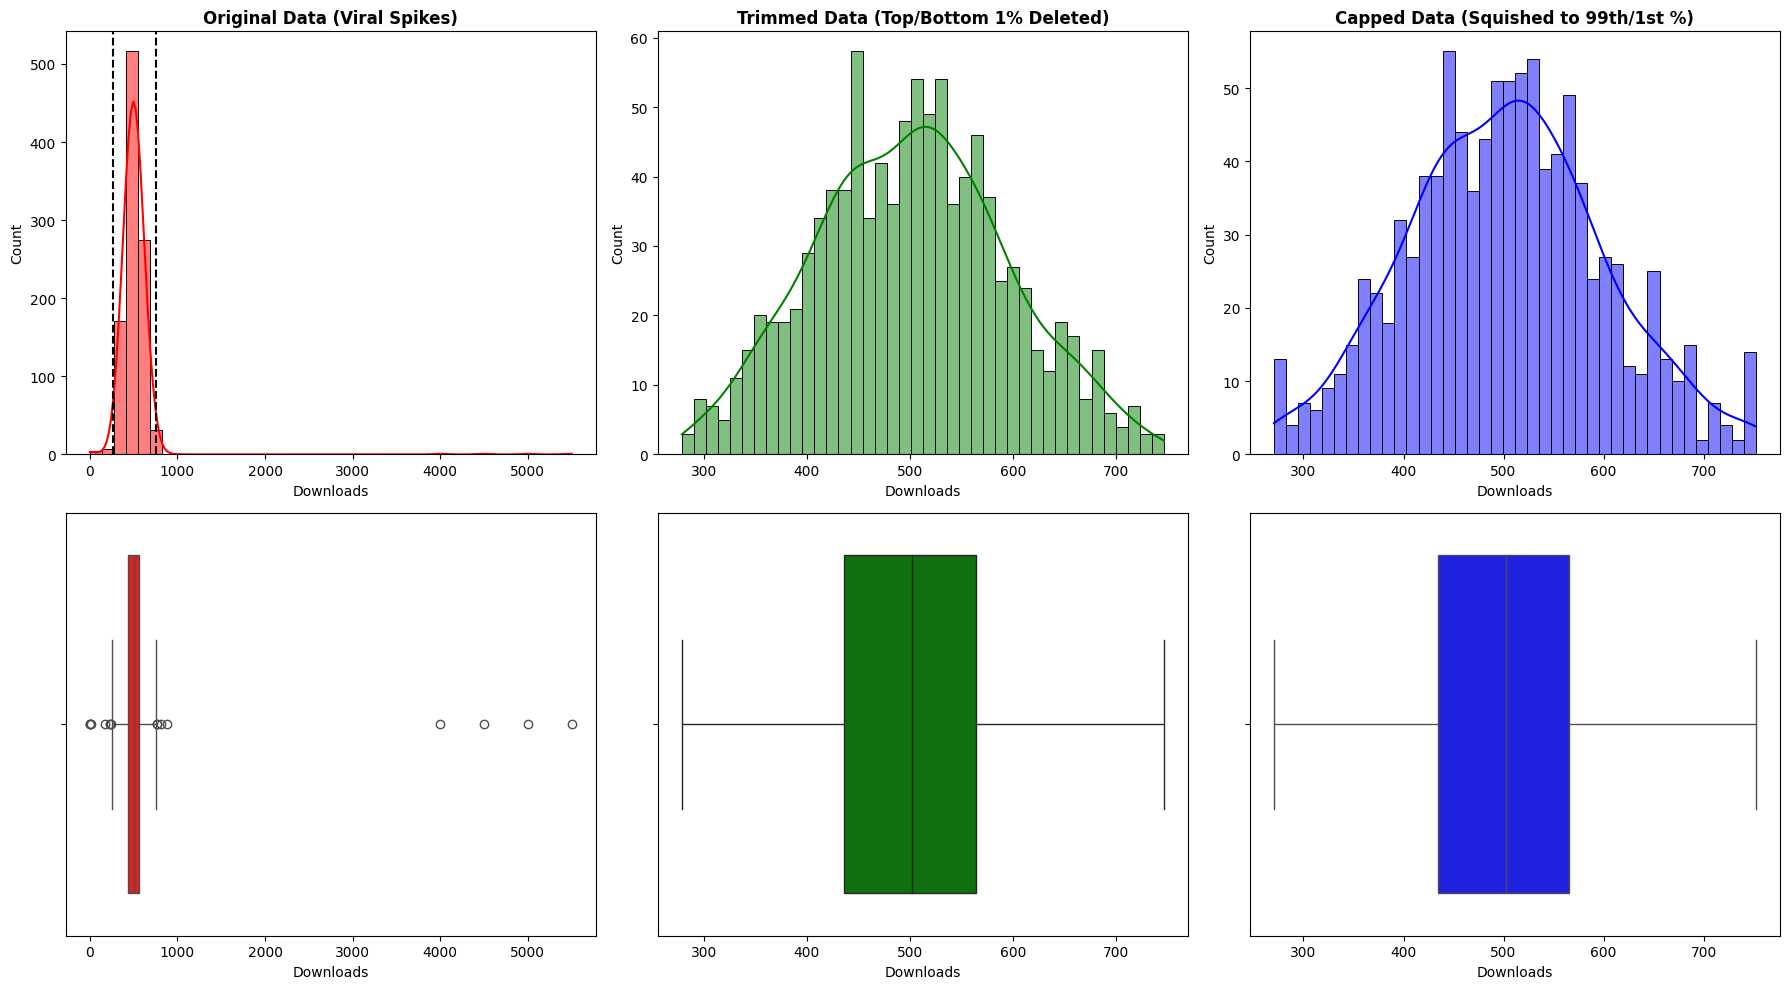

In [10]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Distribution Plots
sns.histplot(df['Downloads'], kde=True, ax=axes[0, 0], color='red', bins=40)
axes[0, 0].set_title('Original Data (Viral Spikes)', fontweight='bold')
axes[0, 0].axvline(upper_limit, color='black', linestyle='--')
axes[0, 0].axvline(lower_limit, color='black', linestyle='--')

sns.histplot(df_trimmed['Downloads'], kde=True, ax=axes[0, 1], color='green', bins=40)
axes[0, 1].set_title('Trimmed Data (Top/Bottom 1% Deleted)', fontweight='bold')

sns.histplot(df_capped['Downloads'], kde=True, ax=axes[0, 2], color='blue', bins=40)
axes[0, 2].set_title('Capped Data (Squished to 99th/1st %)', fontweight='bold')

# Row 2: Boxplots
sns.boxplot(x=df['Downloads'], ax=axes[1, 0], color='red')
sns.boxplot(x=df_trimmed['Downloads'], ax=axes[1, 1], color='green')
sns.boxplot(x=df_capped['Downloads'], ax=axes[1, 2], color='blue')

plt.tight_layout()
plt.show()

##What you should notice:
The power of percentiles is in the control. The math didn't arbitrarily decide where an outlier starts; you decided that the top 1% of days were anomalous viral events that shouldn't train your core predictive model.

Look at the blue Capped plot: you took those insane 5,000-download days and squished them down to match your 99th percentile limit (which is likely around ~800 downloads). This keeps the row of data alive for your model, without letting the extreme 5,000 value ruin your regression weights.